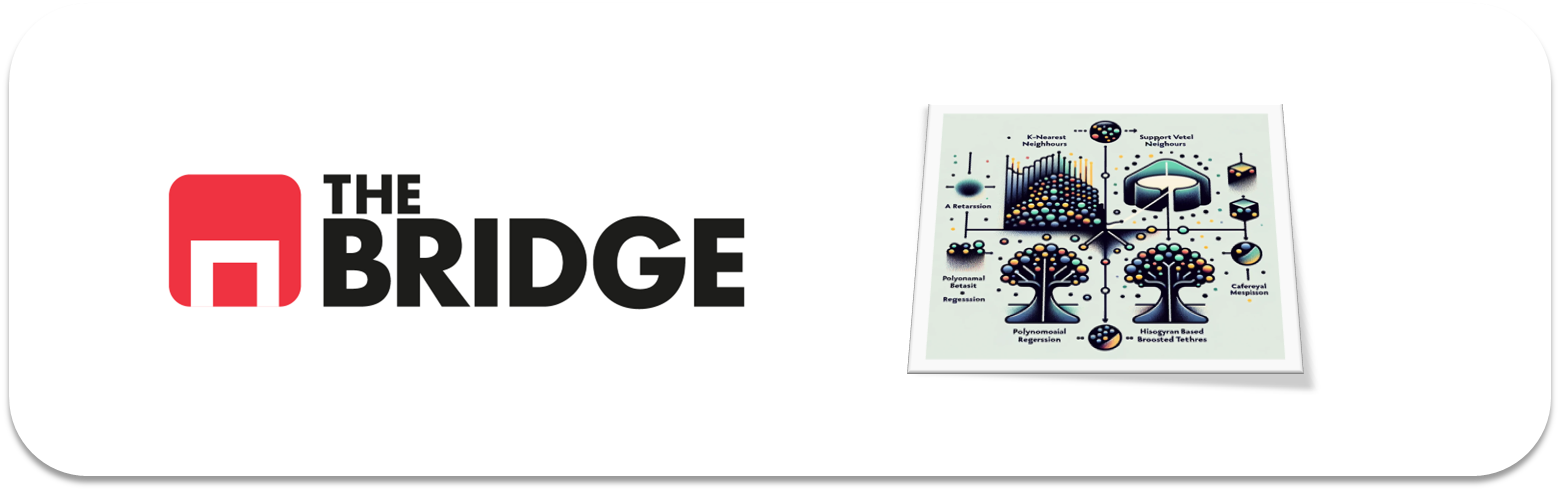

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

In [6]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Importa los paquetes y módulos que necesites a lo largo del notebook.

In [7]:
import bootcampviztools as bt

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.utils import resample
from sklearn.neighbors import KNeighborsClassifier


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier


### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [8]:
df = pd.read_csv("./data/credit_npo.csv")

In [9]:
df.head(10)

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
5,0,0.101002,61,0,0.217115,15880.0,5,0,1,0,0.0
6,0,0.222830,60,0,0.907083,1312.0,5,0,0,0,0.0
7,0,0.353443,39,0,0.764309,4000.0,11,0,1,0,2.0
8,0,0.772455,45,0,0.387179,5100.0,5,0,1,0,3.0
9,0,0.116165,44,0,0.160236,10833.0,8,0,1,0,0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,12537.0,0.068916,0.253321,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,12537.0,0.330359,0.368148,0.0,0.030651,0.163490,0.582219,6.0
age,12537.0,52.079445,15.077498,21.0,41.000000,51.000000,62.000000,101.0
NumberOfTime30-59DaysPastDueNotWorse,12537.0,0.409588,4.055787,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,12537.0,1.902253,9.122216,0.0,0.142268,0.302025,0.506725,99.0
MonthlyIncome,11816.0,6864.815420,11855.905437,0.0,3498.750000,5416.000000,8300.000000,702500.0
NumberOfOpenCreditLinesAndLoans,12537.0,8.482332,5.165422,0.0,5.000000,8.000000,11.000000,49.0
NumberOfTimes90DaysLate,12537.0,0.259312,4.035658,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,12537.0,0.999202,1.134325,0.0,0.000000,1.000000,2.000000,19.0
NumberOfTime60-89DaysPastDueNotWorse,12537.0,0.228364,4.018873,0.0,0.000000,0.000000,0.000000,98.0


PROBLEMA DE CLASIFICACIÓN BINARIA

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Problema de clasificación binaria
Target = SeriousDlqin2yrs

### #1.3
Pinta la distribución de frecuencias del target y coméntala

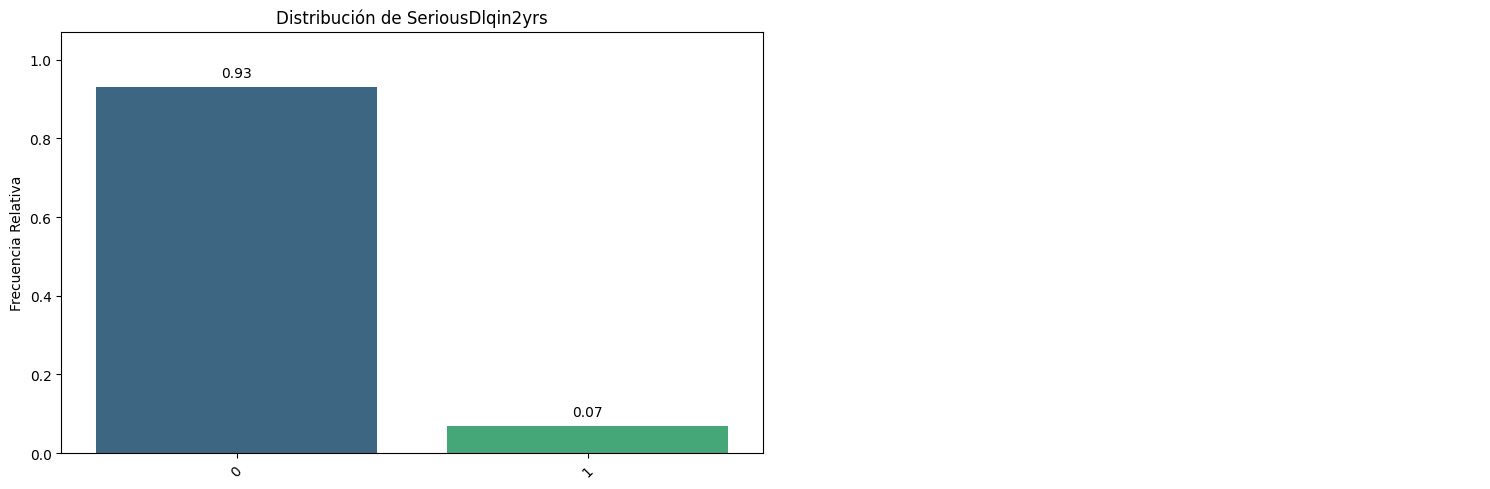

In [12]:
target = 'SeriousDlqin2yrs'

bt.pinta_distribucion_categoricas(df,[target], mostrar_valores=True, relativa=True)

#super desbalanceado

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [13]:
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42, stratify=df['SeriousDlqin2yrs'])

##### IMPUTACIONES

In [14]:
ndp = 'NumberOfDependents'   #variable discreta
mi = 'MonthlyIncome'     #variable continua

In [15]:
train_set[ndp].quantile(0.5)   #hace referncia a la mediana

np.float64(0.0)

In [16]:
mode_train = train_set[ndp].mode()
print(mode_train)

0    0.0
Name: NumberOfDependents, dtype: float64


In [17]:
mode_train = mode_train[0]

train_set[ndp] = train_set[ndp].fillna(mode_train)
test_set[ndp] = test_set[ndp].fillna(mode_train)

In [18]:
train_set[ndp].describe()

count    10029.000000
mean         0.803769
std          1.121366
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         10.000000
Name: NumberOfDependents, dtype: float64

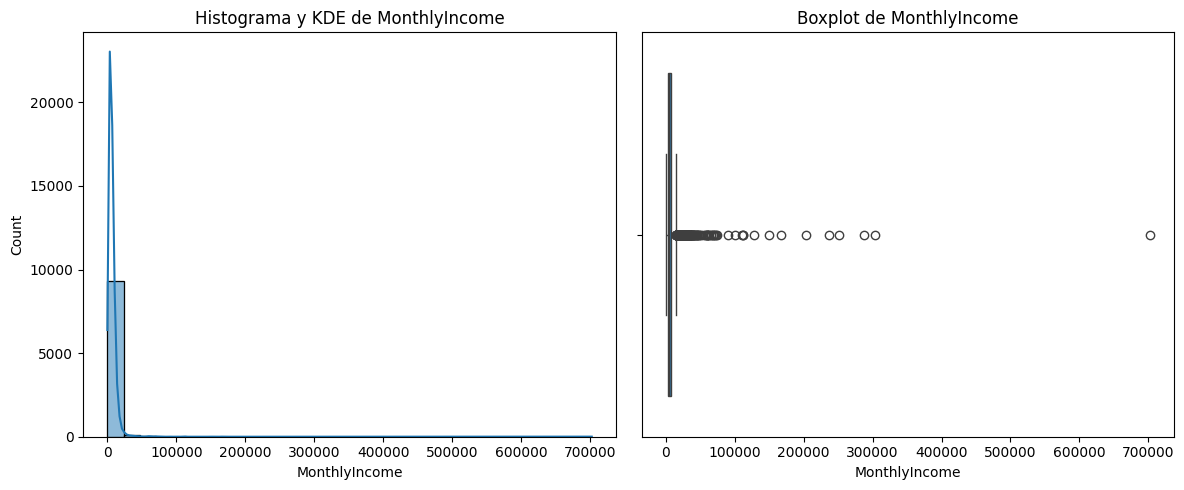

In [19]:
#monthly income

bt.plot_combined_graphs(train_set, columns=[mi], bins=30)

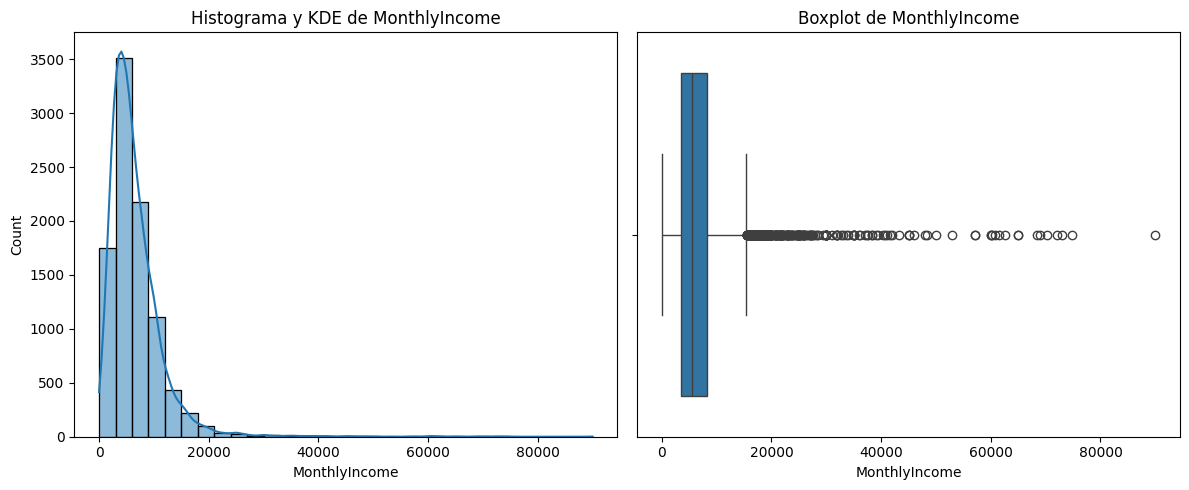

In [20]:
#lo acotamos

bt.plot_combined_graphs(train_set[train_set[mi] < 100000], columns=[mi], bins=30)

c:\Users\pablo.moran\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


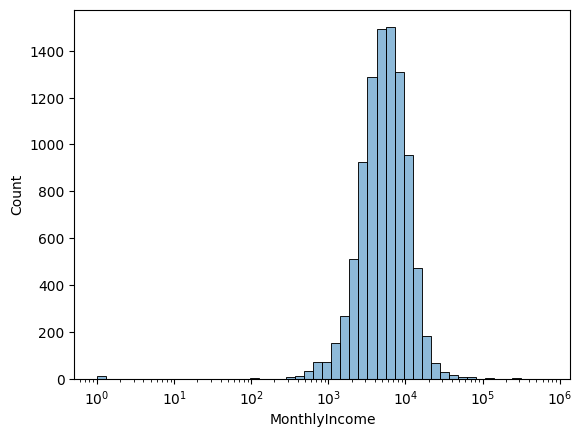

In [21]:
sns.histplot(train_set[mi], bins= 50, kde=True, log_scale=10)
plt.show()

In [22]:
#aplicamos mediana
mediana = train_set[mi].quantile(0.5)

train_set[mi] = train_set[mi].fillna(mediana)
test_set[mi] = test_set[mi].fillna(mediana)

### MINI EDA

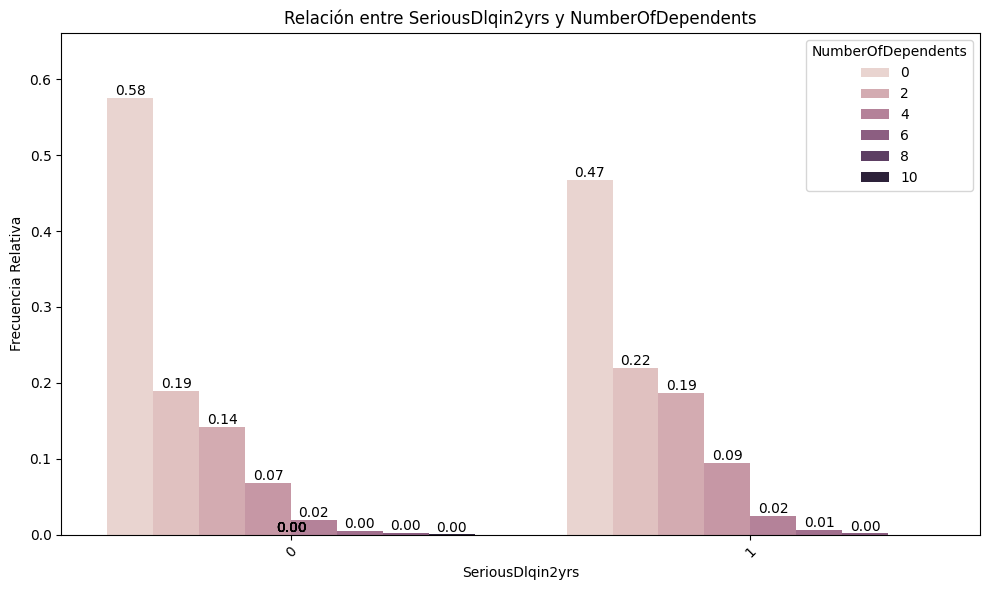

In [23]:
#CATEGORICAS

bt.plot_categorical_relationship(train_set, target, ndp, show_values=True, relative_freq=True)

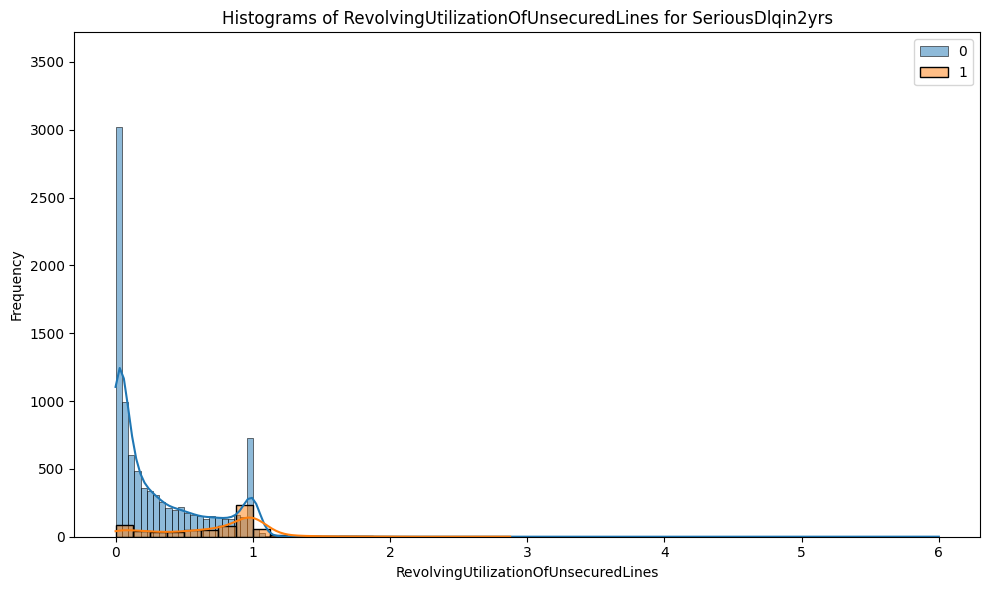

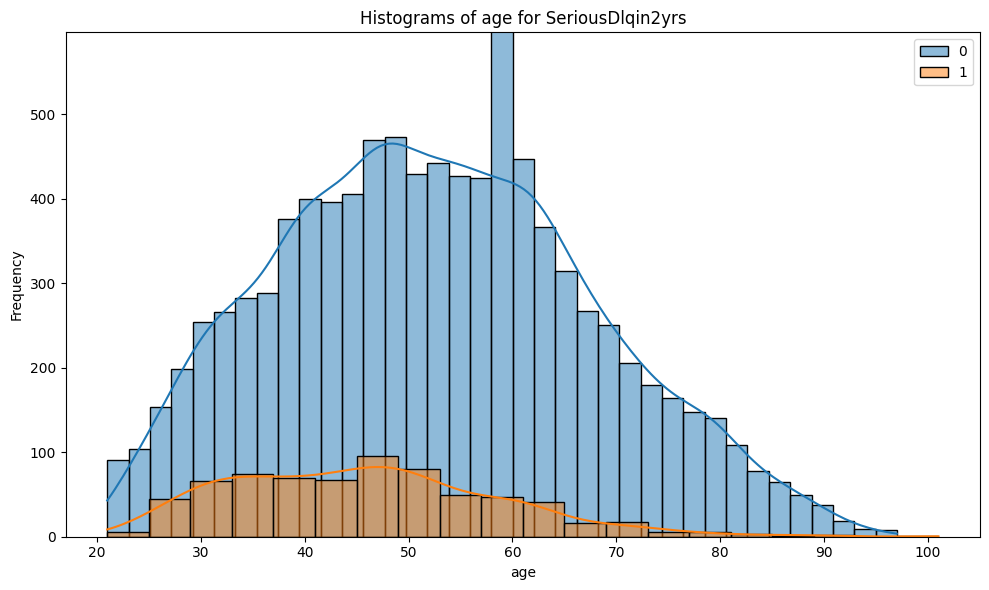

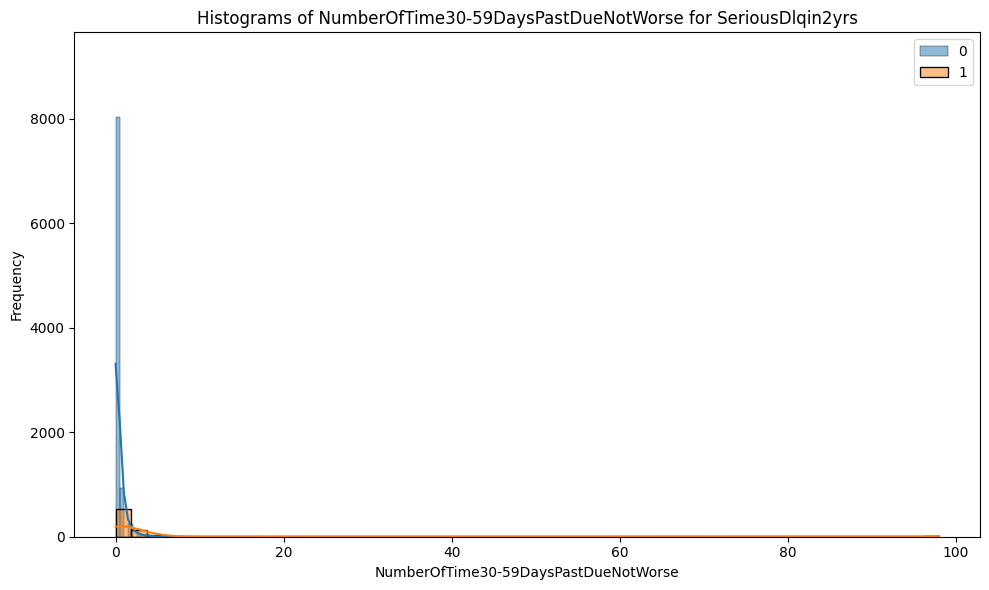

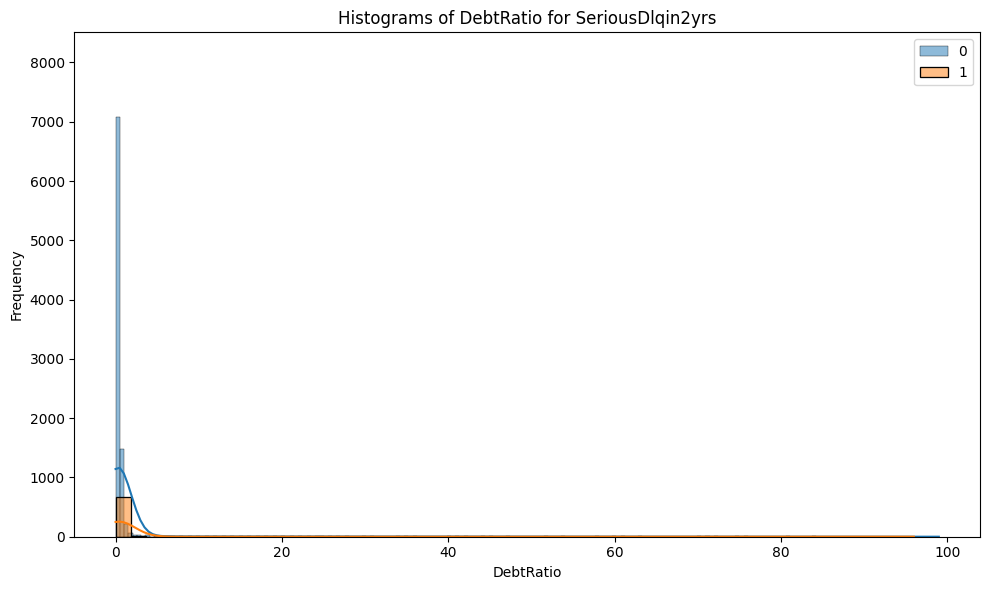

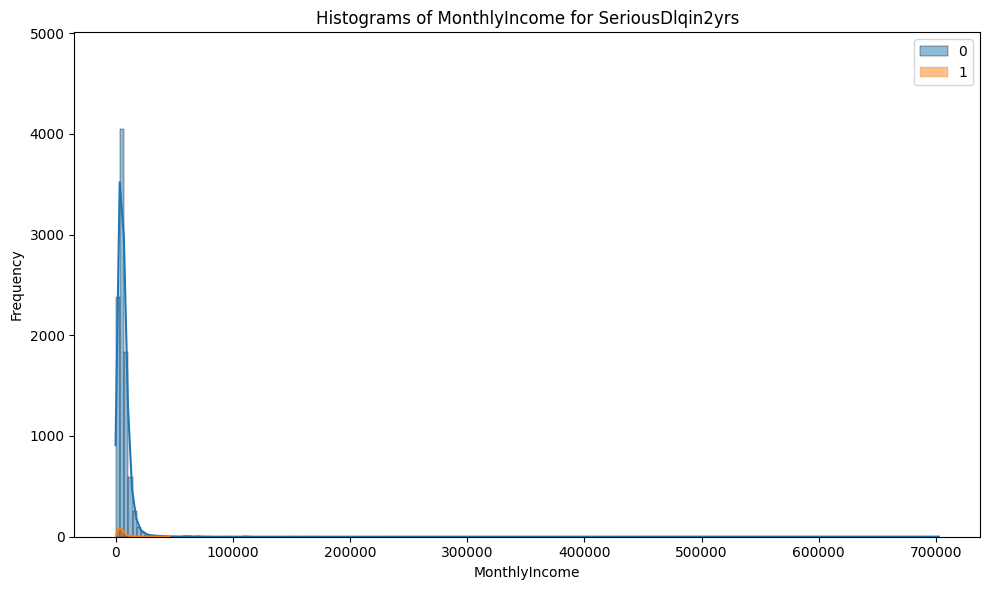

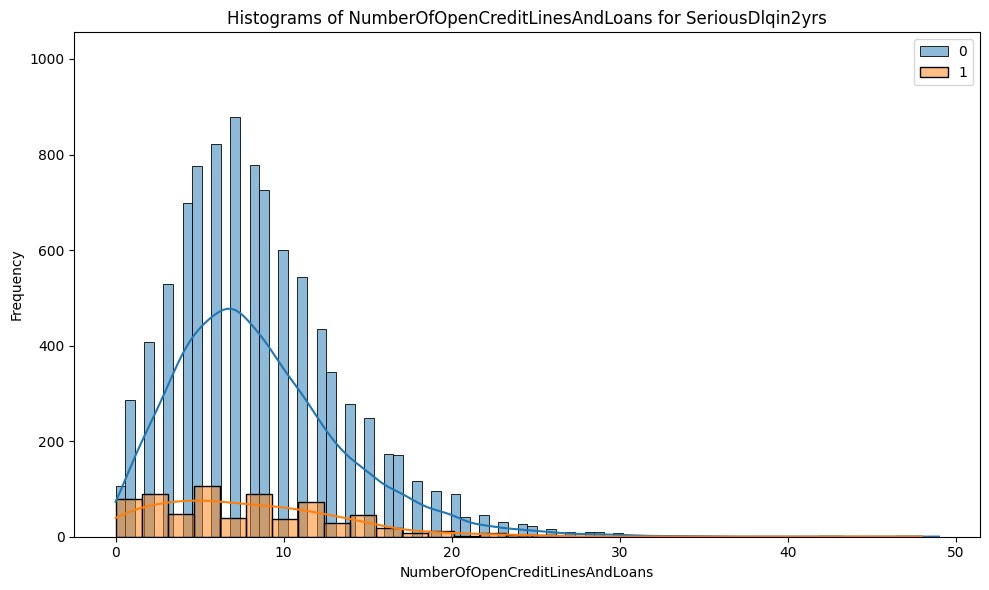

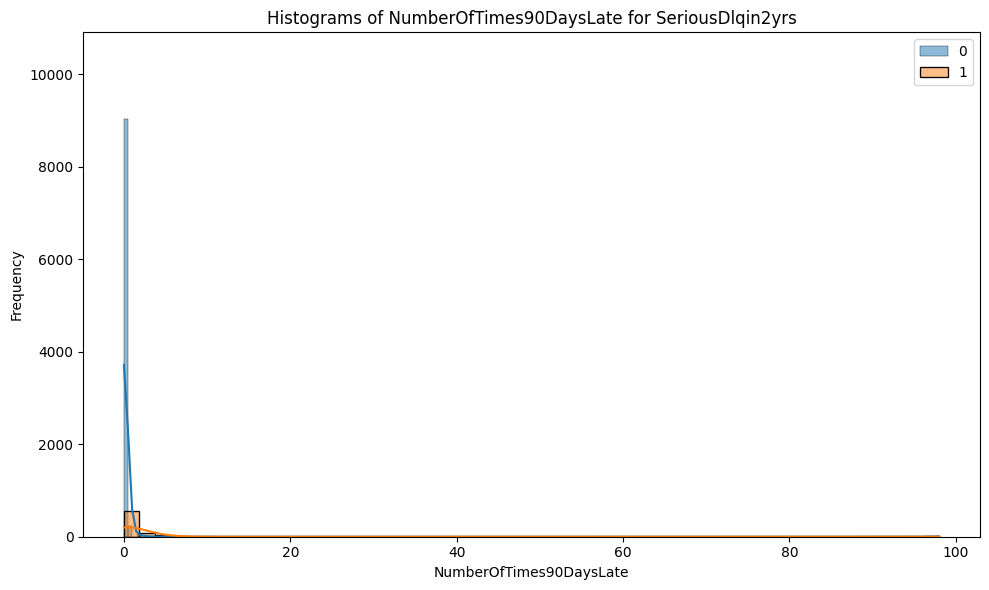

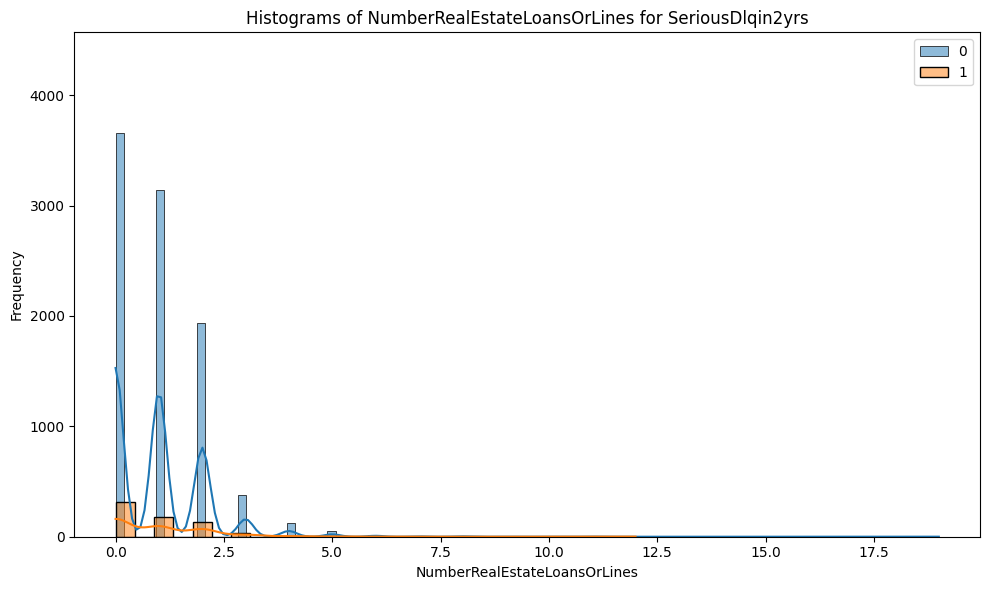

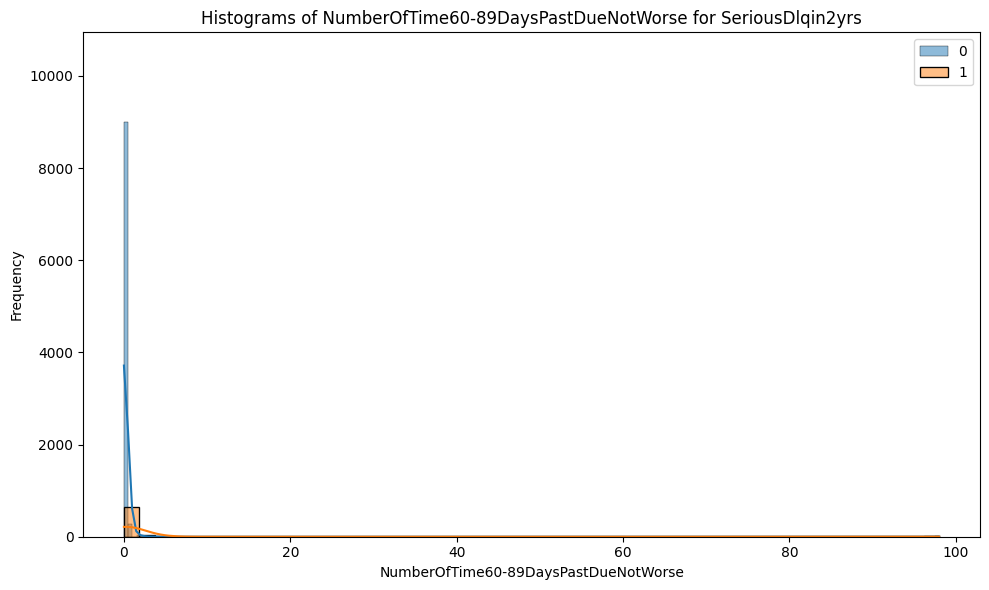

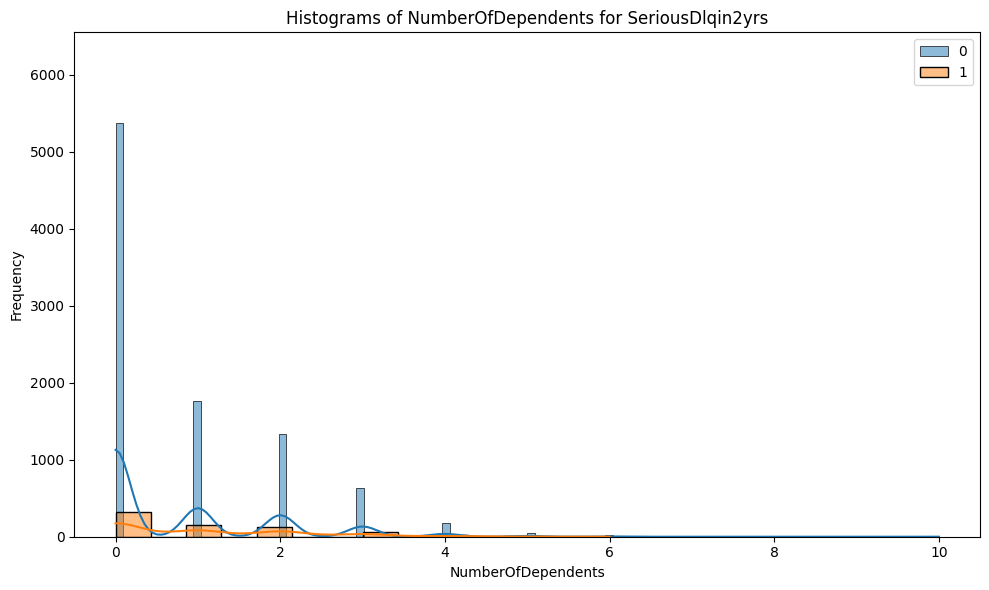

In [24]:
#visualizar las numéricas

features = [col for col in train_set.columns if col!= target]
for col in features:
    bt.plot_grouped_histograms(train_set, cat_col= target,num_col= col, group_size=2)

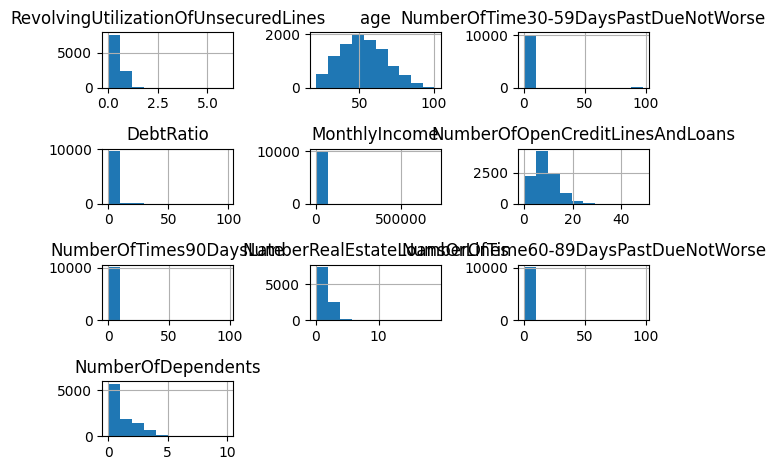

In [25]:
#TRATAMIENTO DE FEATURES
#PRIMERO TRANSFORMAR Y LUEGO SCALAR

train_set[features].hist()
plt.tight_layout()

In [26]:
train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()


In [27]:
for col in features:
    if col != 'age':
        train_set_scaled[col] = np.log(train_set_scaled[col] + 1)
        test_set_scaled[col] = np.log(test_set_scaled[col] + 1)

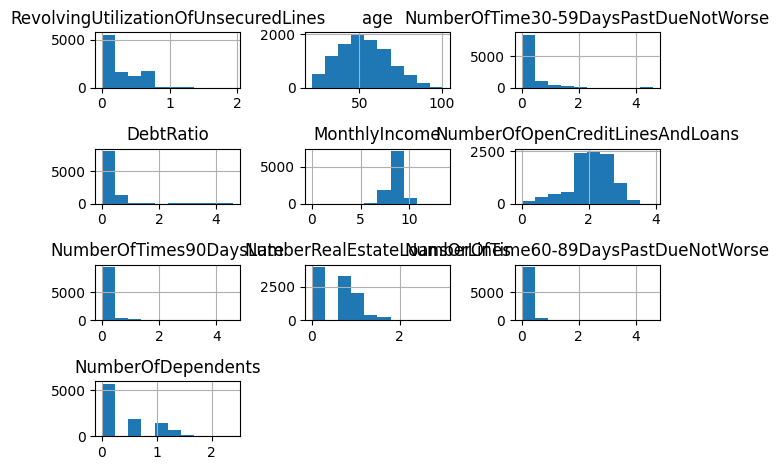

In [28]:
train_set_scaled[features].hist()
plt.tight_layout()

In [29]:
#SCALAR

scaler = StandardScaler()

train_set_scaled[features] = scaler.fit_transform(train_set_scaled[features])
test_set_scaled[features] = scaler.transform(test_set_scaled[features])


In [30]:
X_train = train_set[features]
X_train_scaled = train_set_scaled[features]
y_train = train_set[target]

X_test = test_set[features]
X_test_scaled = test_set_scaled[features]
y_test = test_set[target]

## BASELINE

In [31]:
# KNN

knn_clf = KNeighborsClassifier(n_neighbors=7)

knn_clf.fit(X_train_scaled, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [32]:
print(classification_report(y_train, knn_clf.predict(X_train_scaled)))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      9338
           1       0.69      0.23      0.34       691

    accuracy                           0.94     10029
   macro avg       0.82      0.61      0.66     10029
weighted avg       0.93      0.94      0.93     10029



In [47]:
#empezamos mal. No no está sacando buen modelo

In [33]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [34]:
modelos = ["KNN", "Logistic", "Random", "XGBoost", "LightGBM"]
metricas = []

lr_clf = LogisticRegression(max_iter=10000)
rf_clf = RandomForestClassifier(max_depth=5, random_state=42)
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose= -1, n_jobs = -1)

In [35]:
for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lb_clf]):
    print(f"Para {nombre}:", end = " ")
    if nombre not in modelos [0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv = 5, scoring = "balanced_accuracy"))
    print(metrica)
    metricas.append(metrica)

Para KNN: 0.5738809143505257
Para Logistic: 0.5621148954635444
Para Random: 0.5530236484401414
Para XGBoost: 0.5981654200139266
Para LightGBM: 0.5940385606477767


## Equilibrado


In [ ]:
#PRIMERA TÉCNICA SMOTE


In [36]:
from imblearn.over_sampling import SMOTE


In [37]:
#smote
smote = SMOTE(random_state=42)

In [38]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
X_train_smote_scaled, y_train_smote_scaled = smote.fit_resample(X_train_scaled, y_train)

In [39]:
print(len(y_train))
print(len(y_train_smote))

10029
18676


In [ ]:
#lo visualizaríamos  como eran antes
#y después. Se ve más equilibrada la smote

In [40]:
modelos = ["KNN", "Logistic", "Random", "XGBoost", "LightGBM"]
metricas = []

lr_clf = LogisticRegression(max_iter=10000)
rf_clf = RandomForestClassifier(max_depth=5, random_state=42)
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose= -1, n_jobs = -1)

for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lb_clf]):
    print(f"Para {nombre}:", end = " ")
    if nombre not in modelos [0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train_smote, y_train_smote, cv = 5, scoring = "balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_smote_scaled, y_train_smote_scaled, cv = 5, scoring = "balanced_accuracy"))
    print(metrica)
    metricas.append(metrica)

Para KNN: 0.895588744668186
Para Logistic: 0.7820205611035349
Para Random: 0.8167712862531813
Para XGBoost: 0.9142799427450055
Para LightGBM: 0.8993409998291068


In [ ]:
#SALE TODDO MUCHO MEJOR... EL MEJOR ES EL XGBOOST

In [ ]:
#SEGUNDA TÉCNICA UNDERSAMPLING
#UNDERSAMPLING MANUAL

In [41]:
clase_mayoritaria = X_train[y_train == 0]
clase_minoritaria = X_train[y_train == 1]

clase_mayoritaria_scaled = X_train_scaled[y_train == 0]
clase_minoritaria_scaled = X_train_scaled[y_train == 1]

In [ ]:
clase_mayoritaria_bajomuestreo = resample(clase_mayoritaria, 
                                          replace=False,
                                          n_samples = len(clase_minoritaria),
                                                          random_state=42)

X_train_bajomuestreo = pd.concat([clase_mayoritaria_bajomuestreo, clase_minoritaria])
y_train_bajomuestreo = pd.concat([y_train.loc[clase_mayoritaria_bajomuestreo.index],
                                  y_train.loc[clase_minoritaria.index]])

In [44]:
clase_mayoritaria_bajomuestreo_scl = resample(clase_mayoritaria_scaled, 
                                          replace=False,
                                          n_samples = len(clase_minoritaria_scaled),
                                                          random_state=42) 
X_train_bajomuestreo_scl = pd.concat([clase_mayoritaria_bajomuestreo_scl, clase_minoritaria_scaled])
y_train_bajomuestreo_scl = pd.concat([y_train.loc[clase_mayoritaria_bajomuestreo_scl.index],
                                  y_train.loc[clase_minoritaria_scaled.index]])


In [45]:
modelos = ["KNN", "Logistic", "Random", "XGBoost", "LightGBM"]
metricas = []

lr_clf = LogisticRegression(max_iter=10000)
rf_clf = RandomForestClassifier(max_depth=5, random_state=42)
xgb_clf = XGBClassifier(max_depth=5, random_state=42)
lb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose= -1, n_jobs = -1)

for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lb_clf]):
    print(f"Para {nombre}:", end = " ")
    if nombre not in modelos [0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train_bajomuestreo, y_train_bajomuestreo, cv = 5, scoring = "balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_bajomuestreo_scl, y_train_bajomuestreo_scl, cv = 5, scoring = "balanced_accuracy"))
    print(metrica)
    metricas.append(metrica)

Para KNN: 0.756162026900219
Para Logistic: 0.7720779897820874
Para Random: 0.7655979564174747
Para XGBoost: 0.7366541549369201
Para LightGBM: 0.7482327181732875


In [ ]:
#ha empeorado... mucho mejor logistic

In [ ]:
#HIPERPARÁMETRO
#AJUSTAMOS

In [46]:
modelos = ["KNN", "Logistic", "Random", "XGBoost", "LightGBM"]
metricas = []

knn_clf = KNeighborsClassifier(n_neighbors=7, weights="distance")
lr_clf = LogisticRegression(max_iter=10000, class_weight="balanced")
rf_clf = RandomForestClassifier(max_depth=5, random_state=42, class_weight="balanced")
xgb_clf = XGBClassifier(max_depth=5, random_state=42, scale_pos_weight = len(train_set[train_set[target] == 0]) / len(train_set[train_set[target] == 1]))
lb_clf = LGBMClassifier(max_depth=5, random_state=42, verbose= -1, n_jobs = -1, class_weight="balanced")

for nombre, modelo in zip(modelos, [knn_clf, lr_clf, rf_clf, xgb_clf, lb_clf]):
    print(f"Para {nombre}:", end = " ")
    if nombre not in modelos [0:2]:
        metrica = np.mean(cross_val_score(modelo, X_train, y_train, cv = 5, scoring = "balanced_accuracy"))
    else:
        metrica = np.mean(cross_val_score(modelo, X_train_scaled, y_train, cv = 5, scoring = "balanced_accuracy"))
    print(metrica)
    metricas.append(metrica)

Para KNN: 0.5747895872395858
Para Logistic: 0.7722222977677402
Para Random: 0.764310223682256
Para XGBoost: 0.6756988549419741
Para LightGBM: 0.7441822823703934


In [ ]:
#knn cayó mucho... ganaría Logistic

In [47]:
#a pesar de no ser el ganador, vamos sobre el LGB

#AJUSTAMOS HIPERPARÁMETROS

param_grid = {
    "n_estimators": [100,200],
    "learning_rate": [0.1,0.5,1],
    "max_depth": [5,10,15],
    "min_data_in_leaf": [1,10,20,100],
    "class_weight": ["balanced",None]
}

lgb_clf = LGBMClassifier(verbose=-1, random_state=42)

lgb_grid = GridSearchCV(lgb_clf,
                        param_grid= param_grid,
                        cv = 5,
                        scoring= "balanced_accuracy",
                        n_jobs = -1)

lgb_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced', None], 'learning_rate': [0.1, 0.5, ...], 'max_depth': [5, 10, ...], 'min_data_in_leaf': [1, 10, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [48]:
lgb_grid.best_params_

{'class_weight': 'balanced',
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_data_in_leaf': 100,
 'n_estimators': 100}

In [49]:
lgb_grid.best_score_

np.float64(0.7558565094768038)

In [50]:
print(classification_report(y_test, lgb_grid.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.83      0.90      2335
           1       0.24      0.72      0.36       173

    accuracy                           0.82      2508
   macro avg       0.61      0.78      0.63      2508
weighted avg       0.93      0.82      0.86      2508



In [51]:
#LGB CON SMOTE

param_grid = {
    "n_estimators": [100,200],
    "learning_rate": [0.1,0.5,1],
    "max_depth": [5,10,15],
    "min_data_in_leaf": [1,10,20,100],
}

lgb_clf = LGBMClassifier(verbose=-1, random_state=42)

lgb_grid_smote = GridSearchCV(lgb_clf,
                        param_grid= param_grid,
                        cv = 5,
                        scoring= "balanced_accuracy",
                        n_jobs = -1)

lgb_grid_smote.fit(X_train_smote, y_train_smote)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.5, ...], 'max_depth': [5, 10, ...], 'min_data_in_leaf': [1, 10, ...], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [52]:
print(classification_report(y_test, lgb_grid_smote.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.94      0.95      2335
           1       0.32      0.39      0.35       173

    accuracy                           0.90      2508
   macro avg       0.63      0.66      0.65      2508
weighted avg       0.91      0.90      0.90      2508



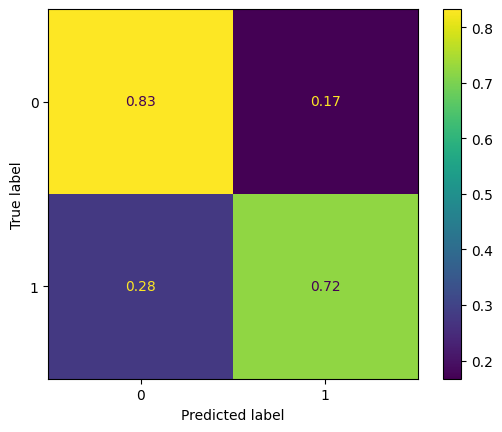

In [56]:
#ANÁLISIS DE ERRORES

ConfusionMatrixDisplay.from_predictions(y_test, lgb_grid.best_estimator_.predict(X_test), normalize = 'true')
plt.show()

In [ ]:
#no está mal... 17% de fuga... pero si es ese quien de tdebe 5.0000000